# Optimising water delivery under constraints

The problem of water allocation can be mathematically described as a combinatorial optimisation problem. We model the system using a small number of water sources, including wells, desalination plants, or purchased water links. Each source is represented by a binary decision qubit indicating whether it is operational. Communities or demand regions can also be represented as qubits to track fulfillment of minimum water requirements. The objective is to maximise the total water delivered while respecting energy and sustainability constraints, which include limits on simultaneous plant operation, sustainable extraction thresholds, and minimum supply targets. These constraints are encoded as penalty terms in a QUBO or Hamiltonian formulation. This toy model illustrates how quantum optimisation can guide water distribution in resource-constrained environments, highlighting potential solutions for real-world sustainability challenges.

In [67]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np

## Generating the graph

In [68]:
def graph(n=None):

    df = pd.read_csv(
        "cities_50largest.csv",
        sep=",",
        header=0,
        names=["city_id", "latitude", "longitude", "population_est"]
    )

    nodes = df[["city_id", "latitude", "longitude", "population_est"]]

    if n is not None:
        nodes = nodes[:n]

    random.seed(42)
    edge_prob = 0.5

    edges = []
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            if random.random() < edge_prob:
                u = int(nodes.iloc[i]["city_id"])
                v = int(nodes.iloc[j]["city_id"])
                weight = random.randint(1, 10)
                edges.append((u, v, weight))

    edges_df = pd.DataFrame(edges, columns=["from_city", "to_city", "weight"])

    return nodes, edges_df

In [125]:
from math import degrees


def graph(n=None):

    df = pd.read_csv(
        "cities_50largest.csv",
        sep=",",
        header=0,
        names=["city_id", "latitude", "longitude", "population_est"]
    )
    nodes = df[["city_id", "latitude", "longitude", "population_est"]]

    if n is not None:
        nodes = nodes[:n]

    limit_distance = 0.4
    def _compute_distance(city_1, city_2):
        delta_long = city_1["longitude"] - city_2["longitude"]
        delta_lat = city_1["latitude"] - city_2["latitude"]
        dist = np.sqrt(delta_long**2 + delta_lat**2)
        return dist

    edges = [[0.0 for _ in range(len(nodes))] for _ in range(len(nodes))]
    for i in range(len(nodes)):
        edges[i][i] = 1.0
        for j in range(i + 1, len(nodes)):
            if _compute_distance(nodes.iloc[i], nodes.iloc[j]) < limit_distance:
                edges[i][j] = 1.0
                edges[j][i] = 1.0
    
    degrees = [sum(row) for row in edges]
    degree = max(degrees)

    return nodes, edges, degree

In [126]:
def plot_graph(nodes, edges):

    plt.figure(figsize=(8, 6))

    for i in range(len(edges)):
        for j in range(i + 1, len(edges[i])):
            if edges[i][j] > 0:
                x1, y1 = nodes.iloc[i][["longitude", "latitude"]]
                x2, y2 = nodes.iloc[j][["longitude", "latitude"]]
                plt.plot([x1, x2], [y1, y2], color="gray", alpha=0.5, linewidth=1)

    plt.scatter(
        nodes["longitude"],
        nodes["latitude"],
        s=nodes["population_est"] / 3000,
        color="tab:blue"
    )

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    #plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

Degree: 11.0


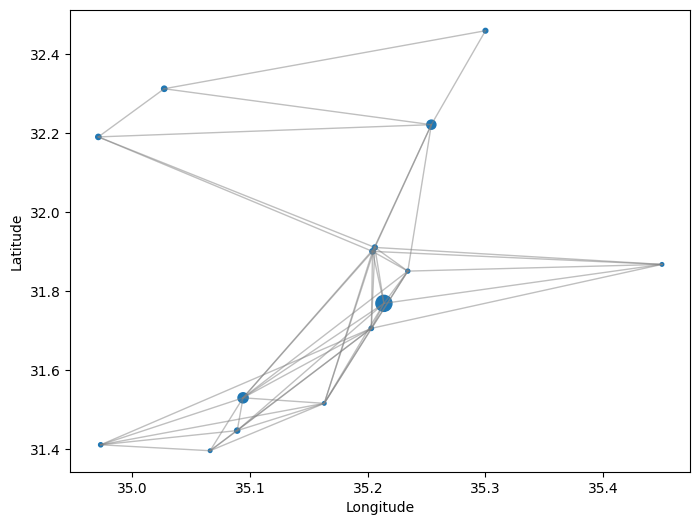

In [127]:
nodes, edges, degree = graph(15)
print("Degree:", degree)
plot_graph(nodes, edges)

## Quantum algorithm

In [72]:
import numpy as np
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals

In [73]:
n = len(nodes) # number of nodes
W = np.sum(edges, axis=1)
mu = 1.1 * degree
S = n // 2
print(f"n: {n}, degree: {degree}, mu: {mu}, S: {S}")

# create a QUBO
qubo = QuadraticProgram()

# define the variables
for i in range(n):
    qubo.binary_var(name=f"x{i}")

# term of the cost function
linear = {f"x{i}": -W[i] for i in range(n)}

quadratic = {}
for i in range(n):
    for j in range(n):
        quadratic[(f"x{i}", f"x{j}")] = mu

for i in range(n):
    linear[f"x{i}"] -= mu * 2 * S

constant = mu * S**2

qubo.minimize(linear=linear, quadratic=quadratic, constant = constant)
print(qubo.prettyprint())

n: 11, degree: 7.0, mu: 7.700000000000001, S: 5
Problem name: 

Minimize
  7.700000000000001*x0^2 + 15.400000000000002*x0*x1 + 15.400000000000002*x0*x10
  + 15.400000000000002*x0*x2 + 15.400000000000002*x0*x3
  + 15.400000000000002*x0*x4 + 15.400000000000002*x0*x5
  + 15.400000000000002*x0*x6 + 15.400000000000002*x0*x7
  + 15.400000000000002*x0*x8 + 15.400000000000002*x0*x9 + 7.700000000000001*x1^2
  + 15.400000000000002*x1*x10 + 15.400000000000002*x1*x2
  + 15.400000000000002*x1*x3 + 15.400000000000002*x1*x4
  + 15.400000000000002*x1*x5 + 15.400000000000002*x1*x6
  + 15.400000000000002*x1*x7 + 15.400000000000002*x1*x8
  + 15.400000000000002*x1*x9 + 7.700000000000001*x10^2
  + 15.400000000000002*x2*x10 + 7.700000000000001*x2^2
  + 15.400000000000002*x2*x3 + 15.400000000000002*x2*x4
  + 15.400000000000002*x2*x5 + 15.400000000000002*x2*x6
  + 15.400000000000002*x2*x7 + 15.400000000000002*x2*x8
  + 15.400000000000002*x2*x9 + 15.400000000000002*x3*x10
  + 7.700000000000001*x3^2 + 15.400000

In [74]:
op, offset = qubo.to_ising()
print("offset: {}".format(offset))
print("operator:")
print(op)

offset: -7.400000000000169
operator:
SparsePauliOp(['IIIIIIIIIIZ', 'IIIIIIIIIZI', 'IIIIIIIIZII', 'IIIIIIIZIII', 'IIIIIIZIIII', 'IIIIIZIIIII', 'IIIIZIIIIII', 'IIIZIIIIIII', 'IIZIIIIIIII', 'IZIIIIIIIII', 'ZIIIIIIIIII', 'IIIIIIIIIZZ', 'IIIIIIIIZIZ', 'IIIIIIIZIIZ', 'IIIIIIZIIIZ', 'IIIIIZIIIIZ', 'IIIIZIIIIIZ', 'IIIZIIIIIIZ', 'IIZIIIIIIIZ', 'IZIIIIIIIIZ', 'ZIIIIIIIIIZ', 'IIIIIIIIZZI', 'IIIIIIIZIZI', 'IIIIIIZIIZI', 'IIIIIZIIIZI', 'IIIIZIIIIZI', 'IIIZIIIIIZI', 'IIZIIIIIIZI', 'IZIIIIIIIZI', 'ZIIIIIIIIZI', 'IIIIIIIZZII', 'IIIIIIZIZII', 'IIIIIZIIZII', 'IIIIZIIIZII', 'IIIZIIIIZII', 'IIZIIIIIZII', 'IZIIIIIIZII', 'ZIIIIIIIZII', 'IIIIIIZZIII', 'IIIIIZIZIII', 'IIIIZIIZIII', 'IIIZIIIZIII', 'IIZIIIIZIII', 'IZIIIIIZIII', 'ZIIIIIIZIII', 'IIIIIZZIIII', 'IIIIZIZIIII', 'IIIZIIZIIII', 'IIZIIIZIIII', 'IZIIIIZIIII', 'ZIIIIIZIIII', 'IIIIZZIIIII', 'IIIZIZIIIII', 'IIZIIZIIIII', 'IZIIIZIIIII', 'ZIIIIZIIIII', 'IIIZZIIIIII', 'IIZIZIIIIII', 'IZIIZIIIIII', 'ZIIIZIIIIII', 'IIZZIIIIIII', 'IZIZIIIIIII', 'ZIIZIIIIIII', 'IZ

In [75]:
# WARM START: solve a continuous relaxation and convert it into a quantum initial state

# Relaxed objective (x is continuous in [0,1], not binary)
def relaxed_objective(x, W, mu, S):
    # Continuous version of the QUBO: min -W·x + mu*(sum(x)-S)^2
    return -np.dot(W, x) + mu * (np.sum(x) - S) ** 2

# Solve the continuous problem to get a smooth starting point
def solve_continuous_relaxation(W, mu, S):
    n = len(W)

    # Initial guess: distribute S uniformly across n variables
    x0 = np.full(n, S / n)
    x0 = np.clip(x0, 0.0, 1.0)

    # Box constraints: each variable stays in [0,1]
    bounds = [(0.0, 1.0)] * n

    # Classical continuous optimization
    result = minimize(
        fun=relaxed_objective,
        x0=x0,
        args=(W, mu, S),
        bounds=bounds,
        method="L-BFGS-B",
    )

    # Final relaxed solution clipped to [0,1]
    c_star = np.clip(result.x, 0.0, 1.0)
    return c_star, result

# Convert c* into a circuit initial state: one Ry angle per qubit
def build_warm_start_initial_state(c_star, eps=1e-6):
    # Avoid exact 0 or 1 to prevent degenerate angles
    c_star = np.clip(c_star, eps, 1 - eps)

    # Warm-start mapping: c_i -> theta_i
    thetas = 2 * np.arcsin(np.sqrt(c_star))

    # Initial-state circuit using Ry(theta_i)
    qc = QuantumCircuit(len(c_star))
    for i, theta in enumerate(thetas):
        qc.ry(theta, i)

    return qc, thetas

# 1) Solve continuous relaxation
c_star, cont_result = solve_continuous_relaxation(W, mu, S)

# 2) Build warm-start initial state for QAOA
warm_start_state, warm_thetas = build_warm_start_initial_state(c_star)

# 3) Print diagnostics
print("Relaxed objective:", cont_result.fun)
print("c*:", np.round(c_star, 4))

Relaxed objective: -35.16883116883105
c*: [0.6948 1.     0.6948 0.     1.     0.     0.     1.     0.     1.
 0.    ]


In [76]:
algorithm_globals.random_seed = 10598
qaoa_mes = QAOA(
    sampler=StatevectorSampler(seed=123),
    optimizer=COBYLA(maxiter=1000),
    reps=5,
    initial_state=warm_start_state,
)
exact_mes = NumPyMinimumEigensolver()

In [77]:
qaoa = MinimumEigenOptimizer(qaoa_mes)  # using QAOA
exact = MinimumEigenOptimizer(exact_mes)  # using the exact classical numpy minimum eigen solver

In [78]:
exact_result = exact.solve(qubo)
print(exact_result.prettyprint())

objective function value: -34.0
variable values: x0=1.0, x1=1.0, x2=0.0, x3=0.0, x4=1.0, x5=0.0, x6=0.0, x7=1.0, x8=0.0, x9=1.0, x10=0.0
status: SUCCESS


In [79]:
qaoa_result = qaoa.solve(qubo)
print(qaoa_result.prettyprint())

objective function value: -34.0
variable values: x0=1.0, x1=1.0, x2=0.0, x3=0.0, x4=1.0, x5=0.0, x6=0.0, x7=1.0, x8=0.0, x9=1.0, x10=0.0
status: SUCCESS


In [83]:
def qaoa_algorithm(nodes, edges, degree):

    n = len(nodes) 
    W = np.sum(edges, axis=1)
    mu = 1.1 * degree
    S = n // 2

    # create a QUBO
    qubo = QuadraticProgram()
    # define the variables
    for i in range(n):
        qubo.binary_var(name=f"x{i}")

    # term of the cost function
    linear = {f"x{i}": -W[i] for i in range(n)}
    quadratic = {}
    for i in range(n):
        for j in range(n):
            quadratic[(f"x{i}", f"x{j}")] = mu
    for i in range(n):
        linear[f"x{i}"] -= mu * 2 * S
    constant = mu * S**2

    qubo.minimize(linear=linear, quadratic=quadratic, constant = constant)
    
    op, offset = qubo.to_ising()

    # WARM START: solve a continuous relaxation and convert it into a quantum initial state
    def relaxed_objective(x, W, mu, S):
        # Continuous version of the QUBO: min -W·x + mu*(sum(x)-S)^2
        return -np.dot(W, x) + mu * (np.sum(x) - S) ** 2

    def solve_continuous_relaxation(W, mu, S):
        n = len(W)
        # Initial guess: distribute S uniformly across n variables
        x0 = np.full(n, S / n)
        x0 = np.clip(x0, 0.0, 1.0)
        # Box constraints: each variable stays in [0,1]
        bounds = [(0.0, 1.0)] * n
        # Classical continuous optimization
        result = minimize(
            fun=relaxed_objective,
            x0=x0,
            args=(W, mu, S),
            bounds=bounds,
            method="L-BFGS-B")
        # Final relaxed solution clipped to [0,1]
        c_star = np.clip(result.x, 0.0, 1.0)
        return c_star, result

    # Convert c* into a circuit initial state: one Ry angle per qubit
    def build_warm_start_initial_state(c_star, eps=1e-6):
        # Avoid exact 0 or 1 to prevent degenerate angles
        c_star = np.clip(c_star, eps, 1 - eps)
        # Warm-start mapping: c_i -> theta_i
        thetas = 2 * np.arcsin(np.sqrt(c_star))
        # Initial-state circuit using Ry(theta_i)
        qc = QuantumCircuit(len(c_star))
        for i, theta in enumerate(thetas):
            qc.ry(theta, i)
        return qc, thetas

    # 1) Solve continuous relaxation
    c_star, cont_result = solve_continuous_relaxation(W, mu, S)
    # 2) Build warm-start initial state for QAOA
    warm_start_state, warm_thetas = build_warm_start_initial_state(c_star)

    algorithm_globals.random_seed = 10598
    qaoa_mes = QAOA(
        sampler=StatevectorSampler(seed=123),
        optimizer=COBYLA(maxiter=1000),
        reps=5,
        initial_state=warm_start_state,
    )

    qaoa = MinimumEigenOptimizer(qaoa_mes)
    qaoa_result = qaoa.solve(qubo)

    probs_df = pd.DataFrame([
        {
            "bitstring": "".join(map(str, sample.x.astype(int))),
            "fval": sample.fval,
            "probability": sample.probability,
        }
        for sample in qaoa_result.samples
    ])

    return probs_df

In [84]:
def qaoa_solution(probs_df):
    
    best_fval = probs_df["fval"].min()
    best_solutions = probs_df[probs_df["fval"] == best_fval].sort_values(
        "probability", ascending=False
    ).reset_index(drop=True)
    return best_solutions

In [85]:
nodes, edges, degree = graph(11)
probs_df = qaoa_algorithm(nodes, edges, degree)

In [87]:
ground_states = qaoa_solution(probs_df)
ground_states

,bitstring,fval,probability
0,01101001010,-34.0,0.224609
1,11001001010,-34.0,0.193359


## Result

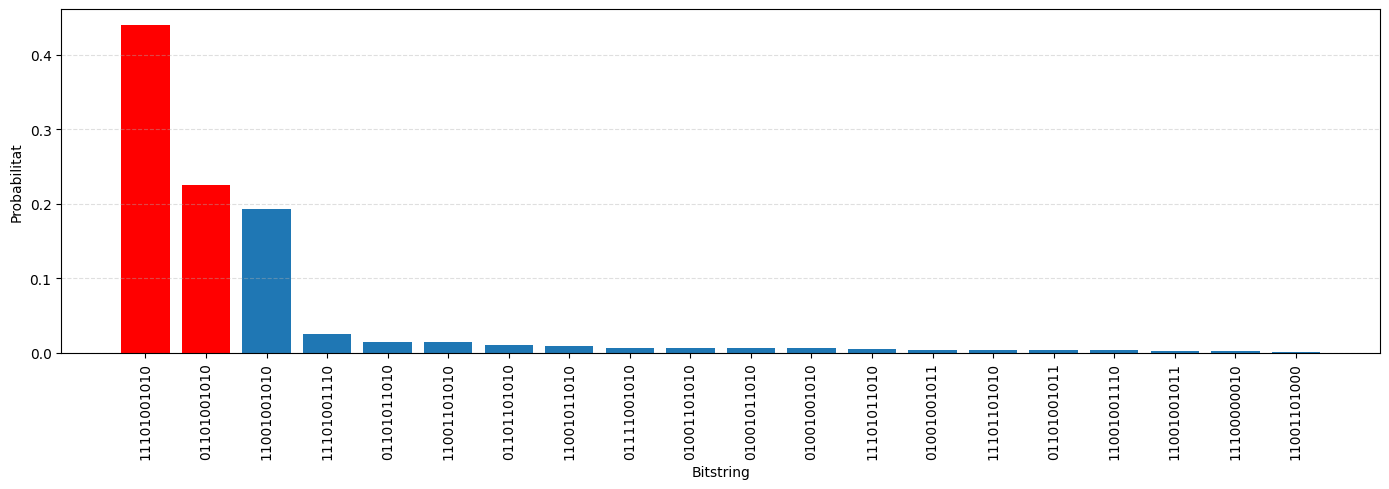

In [88]:
is_min = np.isclose(probs_df["fval"], probs_df["fval"].min())
colors = np.where(is_min, "red", "tab:blue")

probs_df_sorted = probs_df.sort_values("probability", ascending=False)
plt.figure(figsize=(14, 5))
plt.bar(probs_df_sorted["bitstring"][:20], probs_df_sorted["probability"][:20], color=colors)

plt.xlabel("Bitstring")
plt.ylabel("Probabilitat")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

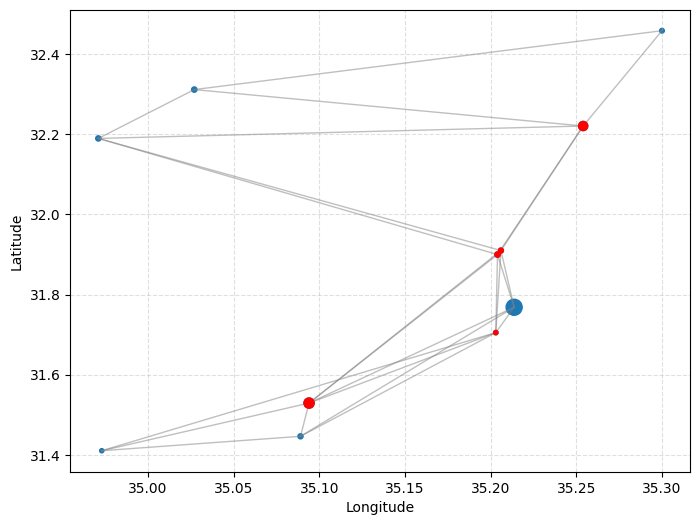

In [89]:
selected_nodes = [i for i in range(n) if ground_states["bitstring"].values[0][i] == '1']

plt.figure(figsize=(8, 6))

for i in range(len(edges)):
    for j in range(i + 1, len(edges[i])):
        if edges[i][j] > 0:
            x1, y1 = nodes.iloc[i][["longitude", "latitude"]]
            x2, y2 = nodes.iloc[j][["longitude", "latitude"]]
            plt.plot([x1, x2], [y1, y2], color="gray", alpha=0.5, linewidth=1)

plt.scatter(
    nodes["longitude"],
    nodes["latitude"],
    s=nodes["population_est"] / 3000,
    color="tab:blue"
)

selected_lons = nodes.iloc[selected_nodes]["longitude"]
selected_lats = nodes.iloc[selected_nodes]["latitude"]
selected_pops = nodes.iloc[selected_nodes]["population_est"]

plt.scatter(
    selected_lons,
    selected_lats,
    s=selected_pops / 3000,
    color="red",
    zorder=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [90]:
import pickle
import time

In [92]:
rows = []

for num_cities in range(4,20):
    nodes, edges, degree = graph(num_cities)

    start_n = time.perf_counter()

    qaoa_result = qaoa_algorithm(nodes, edges, degree)
    ground_states = qaoa_solution(qaoa_result)

    elapsed_n = time.perf_counter() - start_n

    rows.append(
        {
            "num_cities": num_cities,
            "time": elapsed_n,
            "qaoa_result": qaoa_result,
            "ground_states": ground_states,
        }
    )
    print(f"Finished num_cities={num_cities} in {elapsed_n:.2f} seconds")

results_df = pd.DataFrame(rows)
results_df.to_csv("results_df.csv", index=False)

Finished num_cities=4 in 2.40 seconds
Finished num_cities=5 in 2.87 seconds
Finished num_cities=6 in 2.98 seconds
Finished num_cities=7 in 4.69 seconds
Finished num_cities=8 in 6.27 seconds
Finished num_cities=9 in 5.91 seconds
Finished num_cities=10 in 8.10 seconds
Finished num_cities=11 in 10.86 seconds
Finished num_cities=12 in 14.84 seconds
Finished num_cities=13 in 21.00 seconds
Finished num_cities=14 in 59.54 seconds
Finished num_cities=15 in 82.30 seconds
Finished num_cities=16 in 437.75 seconds
Finished num_cities=17 in 742.75 seconds
Finished num_cities=18 in 1320.66 seconds
Finished num_cities=19 in 2460.38 seconds


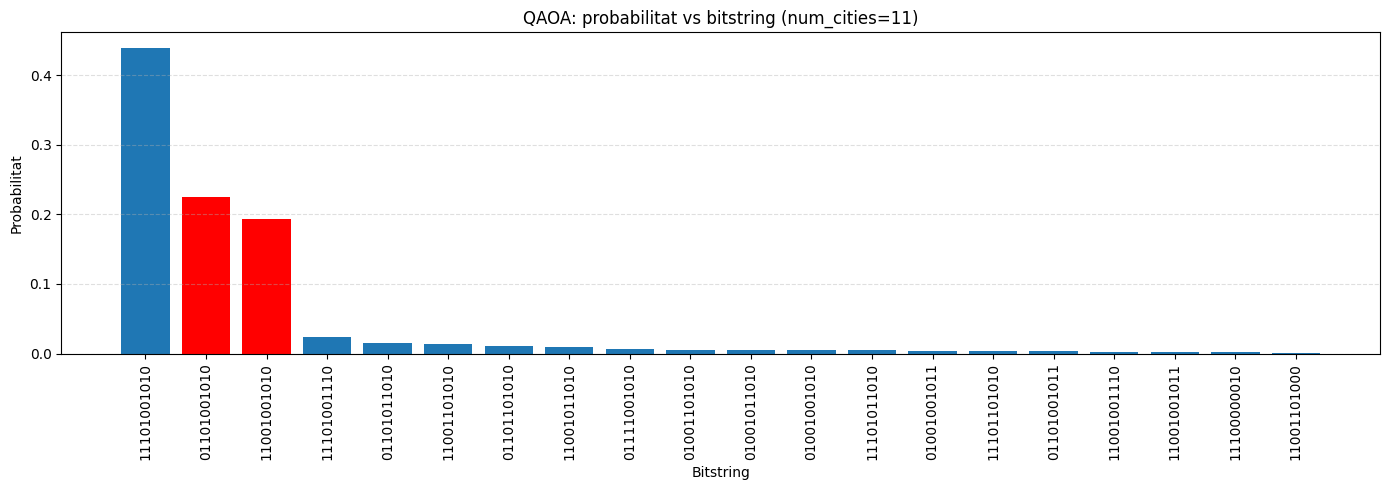

In [143]:
# Llegeix el CSV i extreu el dataframe de probabilitats (bitstring, fval, probability)
loaded_df = pd.read_csv("results_df.csv")

def parse_qaoa_result(text):
    rows = []
    for line in str(text).splitlines():
        line = line.strip()
        if not line or line.startswith("bitstring") or line.startswith("["):
            continue

        parts = line.split()
        # Format habitual: index bitstring fval probability
        if len(parts) >= 4 and parts[0].isdigit():
            _, bitstring, fval, probability = parts[:4]
            rows.append((bitstring, float(fval), float(probability)))
        # Possible format sense índex: bitstring fval probability
        elif len(parts) >= 3 and set(parts[0]).issubset({"0", "1"}):
            bitstring, fval, probability = parts[:3]
            rows.append((bitstring, float(fval), float(probability)))

    return pd.DataFrame(rows, columns=["bitstring", "fval", "probability"])

# Tria el cas a representar
target_num_cities = 11
row = loaded_df.loc[loaded_df["num_cities"] == target_num_cities].iloc[0]
probs_plot_df = parse_qaoa_result(row["qaoa_result"]).sort_values("probability", ascending=False)

# Ressalta estats de mínima energia
is_min = np.isclose(probs_plot_df["fval"], probs_plot_df["fval"].min())
bar_colors = np.where(is_min, "red", "tab:blue")

plt.figure(figsize=(14, 5))
plt.bar(probs_plot_df["bitstring"][:20], probs_plot_df["probability"][:20], color=bar_colors[:20])
plt.xlabel("Bitstring")
plt.ylabel("Probabilitat")
plt.title(f"QAOA: probabilitat vs bitstring (num_cities={target_num_cities})")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()